# dist seguranca

In [1]:
import numpy as np

def check_min_distance(file_path, num_uavs, num_timeslots, min_distance, epoch_total_length):
    try:
        with open(file_path, 'r') as file:
            # Ler o conteúdo do arquivo
            lines = file.readlines()
            # Supondo que a primeira linha contém a melhor solução
            best_solution = list(map(float, lines[0].strip().split()))
            
            # Verificar se o tamanho da solução é compatível
            expected_length = num_uavs * 2 * num_timeslots  # Ajuste para 2 (x, y)
            if len(best_solution) != expected_length:
                print(f"Erro: A solução lida tem {len(best_solution)} elementos, mas esperava {expected_length}.")
                return False
            
            # Extrair as posições dos UAVs
            all_positions = []
            for uav in range(num_uavs):
                uav_positions = []
                for t in range(num_timeslots):
                    idx_x = t * num_uavs * 2 + uav * 2  # Ajuste para 2 (x, y)
                    idx_y = t * num_uavs * 2 + uav * 2 + 1
                    x = best_solution[idx_x]
                    y = best_solution[idx_y]
                    uav_positions.append(np.array([x, y]))
                all_positions.append(uav_positions)
            
            # Verificar a distância mínima em todos os pontos ao longo do trajeto
            for step in range(epoch_total_length + 1):  # Avaliar em cada unidade de distância ao longo do epoch
                for uav in range(num_uavs):
                    start_x, start_y = all_positions[uav][0]  # Posição inicial
                    end_x, end_y = all_positions[uav][-1]  # Posição final
                    
                    alpha = step / epoch_total_length
                    check_x = start_x + alpha * (end_x - start_x)
                    check_y = start_y + alpha * (end_y - start_y)
                    check_position = np.array([check_x, check_y])
                    
                    for other_uav in range(num_uavs):
                        if other_uav != uav:
                            other_start_x, other_start_y = all_positions[other_uav][0]
                            other_end_x, other_end_y = all_positions[other_uav][-1]
                            
                            other_check_x = other_start_x + alpha * (other_end_x - other_start_x)
                            other_check_y = other_start_y + alpha * (other_end_y - other_start_y)
                            other_check_position = np.array([other_check_x, other_check_y])
                            
                            if np.linalg.norm(check_position - other_check_position) < min_distance:
                                print(f"Violação de distância mínima detectada entre UAV {uav} e UAV {other_uav} na posição {check_position}.")
                                return False
            
            print("Todas as posições respeitam a distância mínima de segurança.")
            return True
            
    except Exception as e:
        print(f"Ocorreu um erro ao ler o arquivo: {e}")
        return False

def check_collisions_from_file(file_path, num_uavs, num_timeslots, min_distance=20):
    """
    Lê a melhor solução de um arquivo e verifica colisões apenas nas posições dos timeslots.
    
    Args:
        file_path: Caminho para o arquivo com a solução
        num_uavs: Número de UAVs
        num_timeslots: Número de timeslots
        min_distance: Distância mínima de segurança
    
    Returns:
        tuple: (collision_count, success) - número de colisões e se a leitura foi bem-sucedida
    """
    try:
        with open(file_path, 'r') as file:
            lines = file.readlines()
            # Supondo que a primeira linha contém a melhor solução
            individual = list(map(float, lines[0].strip().split()))
            
            # Verificar se o tamanho da solução é compatível
            expected_length = num_uavs * 2 * num_timeslots
            if len(individual) != expected_length:
                print(f"Erro: A solução lida tem {len(individual)} elementos, mas esperava {expected_length}.")
                return -1, False
            
            collision_count = 0
            violations_details = []
            
            # Verificar cada timeslot
            for t in range(num_timeslots):
                # Extrair posições de todos os UAVs neste timeslot
                positions = []
                for uav in range(num_uavs):
                    idx_x = t * num_uavs * 2 + uav * 2
                    idx_y = t * num_uavs * 2 + uav * 2 + 1
                    x = individual[idx_x]
                    y = individual[idx_y]
                    positions.append(np.array([x, y]))
                
                # Verificar colisões entre todos os pares de UAVs neste timeslot
                for i in range(num_uavs):
                    for j in range(i + 1, num_uavs):
                        distance = np.linalg.norm(positions[i] - positions[j])
                        if distance < min_distance:
                            collision_count += 1
                            violations_details.append({
                                'timeslot': t,
                                'uav1': i,
                                'uav2': j,
                                'pos1': positions[i],
                                'pos2': positions[j],
                                'distance': distance
                            })
            
            # Imprimir resultados
            if collision_count == 0:
                print(f"✓ SUCESSO: Nenhuma colisão encontrada nas posições dos timeslots.")
            else:
                print(f"❌ COLISÕES ENCONTRADAS: {collision_count} violações")
                for violation in violations_details:
                    print(f"  Timeslot {violation['timeslot']}: UAV {violation['uav1']} e UAV {violation['uav2']}")
                    print(f"    Posições: {violation['pos1']} e {violation['pos2']}")
                    print(f"    Distância: {violation['distance']:.2f} < {min_distance}")
            
            return collision_count, True
            
    except Exception as e:
        print(f"Erro ao ler o arquivo: {e}")
        return -1, False


In [2]:
file_path = 'best_solution_epoch.txt'
num_uavs = 4  # Exemplo: número de UAVs
num_timeslots = 6  # Exemplo: número de timeslots
min_distance = 20  # Exemplo: distância mínima de segurança
epoch_total_length = 200  # Exemplo: comprimento total do epoch

# Chamar a função para verificar a distância mínima
check_min_distance(file_path, num_uavs, num_timeslots, min_distance, epoch_total_length)


# Verificar colisões do arquivo
collision_count, success = check_collisions_from_file(
    file_path="best_solution_epoch.txt", 
    num_uavs=4, 
    num_timeslots=6, 
    min_distance=20
)

if success:
    if collision_count == 0:
        print("Sem colisões!")
    else:
        print(f"Encontradas {collision_count} colisões")
else:
    print("Erro ao ler arquivo")



Todas as posições respeitam a distância mínima de segurança.
✓ SUCESSO: Nenhuma colisão encontrada nas posições dos timeslots.
Sem colisões!


In [35]:
limpar_arquivo(file_path)

Arquivo 'D:/Desktop/repo/gym/zzz7_15_2025/multiprocesso copy/best_solution_epoch.txt' foi limpo.


# PLOTAR UAVS _ agora com a dif de angulos


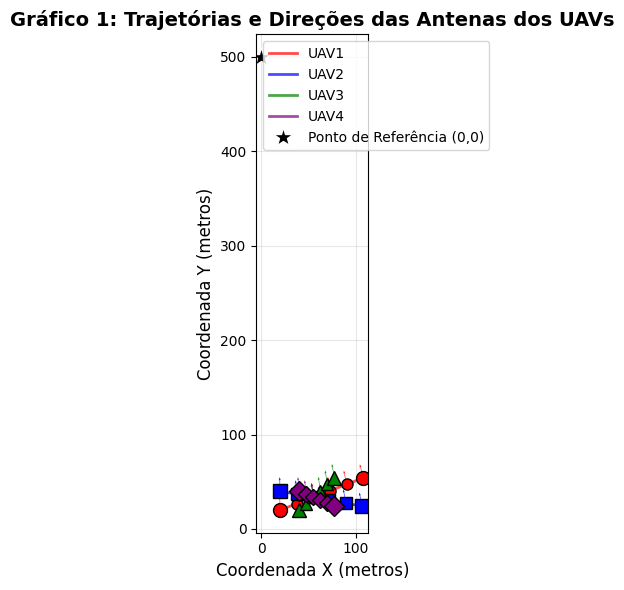


--- Ângulos para o Gráfico 1 ---
Inicial (Posição 1): anguloUAV1= 92.39°, anguloUAV2= 92.49°, anguloUAV3= 94.76°, anguloUAV4= 94.97°
Diferença para ideal: UAV1= 0.00° (ideal: 92.39°), UAV2= 0.00° (ideal: 92.49°), UAV3= 0.00° (ideal: 94.76°), UAV4= 0.00° (ideal: 94.97°)
Coordenadas: UAV1=(20.00, 20.00), UAV2=(20.00, 40.00), UAV3=(40.00, 20.00), UAV4=(40.00, 40.00)

Intermediária 1 (Posição 2): anguloUAV1= 94.54°, anguloUAV2= 94.62°, anguloUAV3= 95.73°, anguloUAV4= 95.84°
Diferença para ideal: UAV1= 0.00° (ideal: 94.54°), UAV2= 0.00° (ideal: 94.62°), UAV3= 0.00° (ideal: 95.73°), UAV4= 0.00° (ideal: 95.84°)
Coordenadas: UAV1=(37.57, 26.81), UAV2=(37.40, 36.81), UAV3=(47.47, 26.83), UAV4=(47.40, 36.76)

Intermediária 2 (Posição 3): anguloUAV1= 96.74°, anguloUAV2= 96.70°, anguloUAV3= 96.72°, anguloUAV4= 96.70°
Diferença para ideal: UAV1= 0.00° (ideal: 96.74°), UAV2= 0.00° (ideal: 96.70°), UAV3= 0.00° (ideal: 96.72°), UAV4= 0.00° (ideal: 96.70°)
Coordenadas: UAV1=(55.14, 33.61), UAV2=(54.79

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math

file_path = 'best_solution_epoch.txt'

NUM_UAVS = 4
REFERENCE_POINT = (0, 500)

def limpar_arquivo(arquivo):
    with open(arquivo, 'w') as file:
        file.write('')
    print(f"Arquivo '{arquivo}' foi limpo.")

def calcular_angulo_ideal(x, y, ref_x, ref_y):
    dx = ref_x - x
    dy = ref_y - y
    angulo_rad = math.atan2(dy, dx)
    angulo_deg = (math.degrees(angulo_rad) + 360) % 360
    return angulo_deg

def normalizar_angulo_graus(angulo):
    return angulo % 360

def diferenca_angular_graus(angulo1, angulo2):
    diff = (angulo1 - angulo2 + 180) % 360 - 180
    return diff

try:
    if NUM_UAVS < 1 or NUM_UAVS > 6:
        raise ValueError("O número de UAVs deve estar entre 1 e 6.")
    
    with open(file_path, 'r') as file:
        content = file.read()

    data_sets = [ds.strip() for ds in content.split('\n\n') if ds.strip()]

    colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown']
    markers = ['o', 's', '^', 'D', 'v', 'p']

    fig, axs = plt.subplots(len(data_sets), 1, figsize=(12, 6 * len(data_sets)))
    if len(data_sets) == 1:
        axs = [axs]

    angle_text = ""

    for i, data_set in enumerate(data_sets):
        values = [float(val) for val in data_set.split()]
        uav_coords = [[] for _ in range(NUM_UAVS)]
        uav_angles = [[] for _ in range(NUM_UAVS)]

        for j in range(0, len(values), 2 * NUM_UAVS):  # Ajuste para 2 (x, y)
            if j + (2 * NUM_UAVS - 1) < len(values):
                for uav_idx in range(NUM_UAVS):
                    x = values[j + uav_idx * 2]
                    y = values[j + uav_idx * 2 + 1]
                    uav_coords[uav_idx].append((x, y))
                    # Calcular o ângulo para o jammer
                    angle = calcular_angulo_ideal(x, y, *REFERENCE_POINT)  # Calcule o ângulo ideal
                    uav_angles[uav_idx].append(angle)  # Armazene o ângulo calculado

        for uav_idx in range(NUM_UAVS):
            if uav_coords[uav_idx]:
                x_coords = [coord[0] for coord in uav_coords[uav_idx]]
                y_coords = [coord[1] for coord in uav_coords[uav_idx]]

                # Plotar trajetória
                axs[i].plot(x_coords, y_coords,
                            color=colors[uav_idx],
                            linestyle='-',
                            linewidth=2,
                            alpha=0.7,
                            label=f'UAV{uav_idx + 1}')
                
                # Plotar posições e setas da direção da antena
                for pos_idx, ((x, y), angle) in enumerate(zip(uav_coords[uav_idx], uav_angles[uav_idx])):
                    # Determinar tamanho do marcador baseado na posição
                    if pos_idx == 0 or pos_idx == len(uav_coords[uav_idx]) - 1:
                        marker_size = 10  # Inicial e final maiores
                    else:
                        marker_size = 8   # Intermediárias menores
                    
                    # Plotar posição
                    axs[i].plot(x, y,
                               marker=markers[uav_idx],
                               color=colors[uav_idx],
                               markersize=marker_size,
                               markeredgecolor='black',
                               markeredgewidth=1)
                    
                    # Calcular direção da antena
                    angle_rad = np.radians(angle)
                    dx = np.cos(angle_rad)
                    dy = np.sin(angle_rad)
                    
                    # Plotar APENAS a seta da direção da antena
                    axs[i].quiver(x, y, dx, dy, 
                                 angles='xy', 
                                 scale_units='xy', 
                                 scale=0.067,  # Tamanho da seta
                                 color=colors[uav_idx], 
                                 width=0.005,  # Espessura da seta
                                 alpha=0.9,
                                 headwidth=4,   # Largura da ponta
                                 headlength=6)  # Comprimento da ponta

        # Plotar ponto de referência
        axs[i].plot(REFERENCE_POINT[0], REFERENCE_POINT[1], 
                   'k*', markersize=15, 
                   label='Ponto de Referência (0,0)',
                   markeredgecolor='white',
                   markeredgewidth=1)

        # Configurações do gráfico
        axs[i].set_title(f'Gráfico {i + 1}: Trajetórias e Direções das Antenas dos UAVs', 
                        fontsize=14, fontweight='bold')
        axs[i].set_xlabel('Coordenada X (metros)', fontsize=12)
        axs[i].set_ylabel('Coordenada Y (metros)', fontsize=12)
        axs[i].grid(True, alpha=0.3)
        axs[i].legend(loc='best', fontsize=10)
        axs[i].set_aspect('equal')

        # Configurar ticks do eixo X
        all_x_coords = []
        for uav_coord_list in uav_coords:
            if uav_coord_list:
                all_x_coords.extend([coord[0] for coord in uav_coord_list])
        all_x_coords.append(REFERENCE_POINT[0])

        if all_x_coords:
            x_min = int(np.floor(min(all_x_coords)))
            x_max = int(np.ceil(max(all_x_coords)))
            axs[i].set_xticks(np.arange(x_min, x_max + 1, 100))

        # Gerar texto com informações dos ângulos
        angle_text += f"\n--- Ângulos para o Gráfico {i + 1} ---\n"
        num_positions = len(uav_angles[0]) if uav_angles[0] else 0

        for pos in range(num_positions):
            position_name = "Inicial" if pos == 0 else ("Final" if pos == num_positions-1 else f"Intermediária {pos}")
            
            angle_info = f"{position_name} (Posição {pos + 1}): "
            diff_info = f"Diferença para ideal: "
            pos_info = f"Coordenadas: "

            for uav_idx in range(NUM_UAVS):
                if pos < len(uav_angles[uav_idx]) and pos < len(uav_coords[uav_idx]):
                    uav_angle = normalizar_angulo_graus(uav_angles[uav_idx][pos])
                    uav_x, uav_y = uav_coords[uav_idx][pos]
                    ideal_angle = calcular_angulo_ideal(uav_x, uav_y, *REFERENCE_POINT)
                    diff = diferenca_angular_graus(uav_angle, ideal_angle)

                    angle_info += f"anguloUAV{uav_idx + 1}= {uav_angle:.2f}°"
                    diff_info += f"UAV{uav_idx + 1}= {diff:.2f}° (ideal: {ideal_angle:.2f}°)"
                    pos_info += f"UAV{uav_idx + 1}=({uav_x:.2f}, {uav_y:.2f})"

                    if uav_idx < NUM_UAVS - 1:
                        angle_info += ", "
                        diff_info += ", "
                        pos_info += ", "

            angle_text += angle_info + "\n" + diff_info + "\n" + pos_info + "\n\n"

    plt.tight_layout()
    plt.show()
    print(angle_text)

    #limpar_arquivo(file_path)

except FileNotFoundError:
    print(f"Erro: O arquivo '{file_path}' não foi encontrado.")
except ValueError as ve:
    print(f"Erro de valor: {ve}")
except Exception as e:
    print(f"Erro ao processar o arquivo: {e}")


In [18]:
limpar_arquivo(file_path)

Arquivo 'D:/Desktop/repo/gym/zzz7_15_2025/multiprocesso copy/best_solution_epoch.txt' foi limpo.


# valores fitness

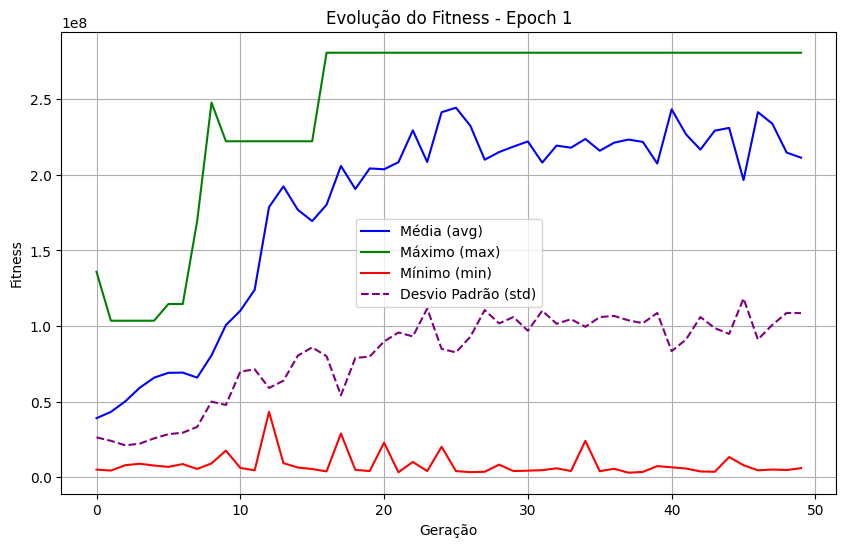

In [7]:
import matplotlib.pyplot as plt

def limpar_arquivo(arquivo):
    # Função para limpar o arquivo
    with open(arquivo, 'w') as file:
        file.write('')
    print(f"Arquivo '{arquivo}' foi limpo.")

def plot_fitness_from_file(filename="fitness_values.txt"):
    """
    Lê os dados do arquivo e plota os gráficos de fitness para cada epoch.
    
    Args:
        filename (str): Nome do arquivo contendo os dados de fitness.
    """
    #########DEFENIR ANTES DE CORRER#######

    num_epochs = 1 # Defina o número de epochs que você deseja plotar

    #######################################
    
    # Dicionário para armazenar os dados de cada epoch
    epochs_data = {}
    
    # Ler o arquivo
    with open(filename, "r") as file:
        current_epoch = None
        for line in file:
            line = line.strip()
            if line.startswith("=== Epoch"):
                # Iniciar um novo epoch
                current_epoch = int(line.split(" ")[2])  # Extrair o número do epoch
                epochs_data[current_epoch] = {"gen": [], "avg": [], "max": [], "min": [], "std": []}
            elif line.startswith("gen"):
                # Ignorar o cabeçalho
                continue
            elif line and current_epoch is not None:
                # Ler os valores da geração
                gen, avg, max_val, min_val, std = line.split("\t")
                epochs_data[current_epoch]["gen"].append(int(gen))
                epochs_data[current_epoch]["avg"].append(float(avg))
                epochs_data[current_epoch]["max"].append(float(max_val))
                epochs_data[current_epoch]["min"].append(float(min_val))
                epochs_data[current_epoch]["std"].append(float(std))
    
    # Plotar os gráficos para cada epoch
    for epoch in range(1, num_epochs + 1):
        if epoch not in epochs_data:
            print(f"Dados para o Epoch {epoch} não encontrados.")
            continue
        
        data = epochs_data[epoch]
        plt.figure(figsize=(10, 6))
        plt.plot(data["gen"], data["avg"], label="Média (avg)", color="blue")
        plt.plot(data["gen"], data["max"], label="Máximo (max)", color="green")
        plt.plot(data["gen"], data["min"], label="Mínimo (min)", color="red")
        plt.plot(data["gen"], data["std"], label="Desvio Padrão (std)", color="purple", linestyle="--")
        
        plt.title(f"Evolução do Fitness - Epoch {epoch}")
        plt.xlabel("Geração")
        plt.ylabel("Fitness")
        plt.legend()
        plt.grid(True)
        plt.show()


# Exemplo de uso
plot_fitness_from_file()
#limpar_arquivo('fitness_values.txt')

In [30]:
limpar_arquivo('fitness_values.txt')

Arquivo 'fitness_values.txt' foi limpo.


# plot mais recente

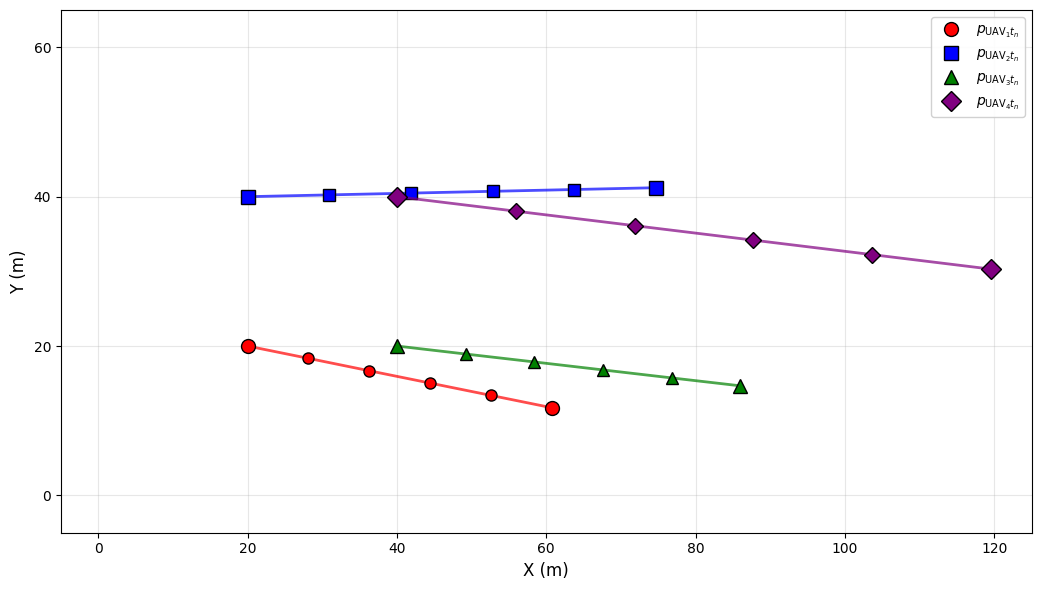

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.lines import Line2D

file_path = 'best_solution_epoch.txt'
NUM_UAVS = 4

def limpar_arquivo(arquivo):
    with open(arquivo, 'w') as file:
        file.write('')
    print(f"Arquivo '{arquivo}' foi limpo.")

try:
    if NUM_UAVS < 1 or NUM_UAVS > 6:
        raise ValueError("O número de UAVs deve estar entre 1 e 6.")
    
    with open(file_path, 'r') as file:
        content = file.read()

    data_sets = [ds.strip() for ds in content.split('\n\n') if ds.strip()]

    colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown']
    markers = ['o', 's', '^', 'D', 'v', 'p']

    fig, axs = plt.subplots(len(data_sets), 1, figsize=(12, 6 * len(data_sets)))
    if len(data_sets) == 1:
        axs = [axs]

    for i, data_set in enumerate(data_sets):
        values = [float(val) for val in data_set.split()]
        uav_coords = [[] for _ in range(NUM_UAVS)]

        for j in range(0, len(values), 2 * NUM_UAVS):  # Ajuste para (x, y)
            if j + (2 * NUM_UAVS - 1) < len(values):
                for uav_idx in range(NUM_UAVS):
                    x = values[j + uav_idx * 2]
                    y = values[j + uav_idx * 2 + 1]
                    uav_coords[uav_idx].append((x, y))

        for uav_idx in range(NUM_UAVS):
            if uav_coords[uav_idx]:
                x_coords = [coord[0] for coord in uav_coords[uav_idx]]
                y_coords = [coord[1] for coord in uav_coords[uav_idx]]

                # Plotar trajetória
                axs[i].plot(x_coords, y_coords,
                            color=colors[uav_idx],
                            linestyle='-',
                            linewidth=2,
                            alpha=0.7)

                # Plotar posições (sem setas)
                for pos_idx, (x, y) in enumerate(uav_coords[uav_idx]):
                    marker_size = 10 if pos_idx in [0, len(uav_coords[uav_idx]) - 1] else 8
                    axs[i].plot(x, y,
                               marker=markers[uav_idx],
                               color=colors[uav_idx],
                               markersize=marker_size,
                               markeredgecolor='black',
                               markeredgewidth=1)

        # Configurações do gráfico
        axs[i].set_xlabel('X (m)', fontsize=12)
        axs[i].set_ylabel('Y (m)', fontsize=12)
        axs[i].grid(True, alpha=0.3)

        # Definir limites fixos conforme pedido
        axs[i].set_xlim(-5, 125)
        axs[i].set_ylim(-5, 65)

        # Definir ticks em passos de 20 (0,20,40,...)
        axs[i].set_xticks(np.arange(0, 125, 20))
        axs[i].set_yticks(np.arange(0, 65, 20))

        axs[i].set_aspect('equal', adjustable='box')

        # --- Legenda personalizada com marcadores e rótulos LaTeX ---
        handles = []
        labels = []
        for uav_idx in range(NUM_UAVS):
            handle = Line2D([0], [0],
                            marker=markers[uav_idx],
                            color='w',  # linha invisível
                            markerfacecolor=colors[uav_idx],
                            markeredgecolor='black',
                            markersize=10,
                            linestyle='')
            handles.append(handle)
            # rótulo em LaTeX: p_{\mathrm{UAV}_{i,t_T}}
            labels.append(r"$p_{\text{UAV}_{%d}t_n}$" % (uav_idx + 1))

        axs[i].legend(handles, labels, loc='best', fontsize=10, framealpha=0.9)

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"Erro: O arquivo '{file_path}' não foi encontrado.")
except ValueError as ve:
    print(f"Erro de valor: {ve}")
except Exception as e:
    print(f"Erro ao processar o arquivo: {e}")
